In [1]:
# notebooks/ sits one level down, so point at the lesson modules and data.
# Written to be safe to re-run: it moves up only if it is not already there.
import sys, os
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')
sys.path.insert(0, os.getcwd())
%matplotlib inline
print('working directory:', os.getcwd())

working directory: /home/user/chiu__2022_rerun/tk_learning


# Lesson 4 — Nonlinear least squares: fit the curve, not a transform of it

Log-linear regression (lesson 03) works only because the one-compartment
IV model happens to become a straight line under a log. Nothing else in
PK does. The general method is to write the model as a function, hand it
to an optimiser, and let it search for the parameters that minimise the
squared residuals.

We use scipy.optimize.curve_fit. Everything from here on -- oral models,
two compartments, PBPK -- uses the same machinery.

In [2]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit

import plotting as P
from tk import load, iv_1comp, half_life, clearance

P.setup()

mk = load("PFOA_Male_primate")
one = mk[(mk.animal_id == 2054) & (mk.conc_mgL > 0)].sort_values("time_d")
t, C, DOSE = one.time_d.values, one.conc_mgL.values, 10.0

## A. The fit, on the log scale

In [3]:
def model_log(t, ln_Vd, ln_k):
    """Predict ln C. Fitting the LOG of the parameters keeps them
    positive without constraints, and fitting the LOG of the prediction
    is what makes the residuals multiplicative (lesson 03, trap 2)."""
    return np.log(iv_1comp(t, DOSE, np.exp(ln_Vd), np.exp(ln_k)))


p0 = [np.log(0.2), np.log(0.07)]
popt, pcov = curve_fit(model_log, t, np.log(C), p0=p0)
Vd, k = np.exp(popt)
# curve_fit returns the covariance of the LOG parameters; on the log
# scale a standard error is (approximately) a relative standard error.
se_ln = np.sqrt(np.diag(pcov))

print("A. One-compartment IV fit by nonlinear least squares\n")
print(f"   Vd        = {Vd:8.4f} L/kg    (x/ {np.exp(1.96*se_ln[0]):.2f} 95% CI)")
print(f"   k         = {k:8.4f} 1/day   (x/ {np.exp(1.96*se_ln[1]):.2f} 95% CI)")
print(f"   half-life = {half_life(k):8.2f} days")
print(f"   clearance = {clearance(k, Vd):8.5f} L/kg/day")

A. One-compartment IV fit by nonlinear least squares

   Vd        =   0.1873 L/kg    (x/ 1.42 95% CI)
   k         =   0.0807 1/day   (x/ 1.16 95% CI)
   half-life =     8.59 days
   clearance =  0.01512 L/kg/day


Log-linear regression on the same points (lesson 03) gave exactly the
same numbers: t1/2 8.59 d, Vd 0.187 L/kg. That is the point -- for
this one model the two methods minimise the same objective, so they
must agree, and matching them is how you check the harder machinery
before you trust it on models where no closed form exists.

What NLS adds is a covariance matrix, and the ability to fit any
model you can write down.

## B. Look at the residuals. Always.

In [4]:
pred = iv_1comp(t, DOSE, Vd, k)
res = np.log(C / pred)
print(f"   {'t (d)':>8s} {'obs':>9s} {'pred':>9s} {'ln(obs/pred)':>13s}")
for ti, ci, pi, ri in zip(t, C, pred, res):
    bar = "#" * int(abs(ri) * 20)
    side = " " * 12 if ri < 0 else ""
    print(f"   {ti:8.3f} {ci:9.3f} {pi:9.3f} {ri:13.3f}  {side}{bar}")

runs = np.sum(np.diff(np.sign(res)) != 0) + 1
print(f"\n   {runs} runs of the same sign in {len(res)} residuals.")

      t (d)       obs      pred  ln(obs/pred)
      0.021    96.660    53.295         0.595  ###########
      0.083    91.630    53.027         0.547  ##########
      0.167    89.160    52.671         0.526  ##########
      0.333    60.860    51.968         0.158  ###
      1.000    50.930    49.246         0.034  
      2.000    48.530    45.428         0.066  #
      4.000    42.940    38.657         0.105  ##
      7.000    27.910    30.345        -0.084              #
     11.000    19.320    21.974        -0.129              ##
     14.000    11.220    17.249        -0.430              ########
     21.000     3.990     9.805        -0.899              #################
     28.000     1.860     5.574        -1.097              #####################
     57.000     0.470     0.537        -0.133              ##
     87.000     0.100     0.048         0.740  ##############

   3 runs of the same sign in 14 residuals.


A good fit scatters residuals randomly around zero. These do not:
strongly positive for the first few days, drifting down through zero,
sharply negative around days 14-28, then positive again at the very
end. Only three sign changes in fourteen points -- neighbouring
residuals are almost perfectly predictable from each other. That
systematic pattern is the model being wrong, not the data being noisy.
No amount of better optimisation fixes it -- you need a better model.

This is the single most useful habit in modelling: plot the residuals
against time, and against the prediction. The pattern tells you what
is missing.

## C. Uncertainty is not the same as correctness

In [5]:
corr = pcov[0, 1] / np.sqrt(pcov[0, 0] * pcov[1, 1])
se_CL = np.sqrt(pcov[0, 0] + pcov[1, 1] + 2 * pcov[0, 1])   # var(lnVd + lnk)
se_indep = np.sqrt(pcov[0, 0] + pcov[1, 1])                 # if they were independent
print(f"   correlation between ln Vd and ln k: {corr:+.2f}\n")
print(f"   {'quantity':22s} {'95% interval':>14s}")
for nm, sd in [("Vd", se_ln[0]), ("k", se_ln[1]), ("CL = k*Vd", se_CL),
               ("CL if k,Vd were indep", se_indep)]:
    print(f"   {nm:22s} {'x/ ' + format(np.exp(1.96 * sd), '.2f'):>14s}")

   correlation between ln Vd and ln k: -0.56

   quantity                 95% interval
   Vd                            x/ 1.42
   k                             x/ 1.16
   CL = k*Vd                     x/ 1.35
   CL if k,Vd were indep         x/ 1.47


The two parameters trade off: a larger Vd lowers the whole curve, and
the optimiser can partly compensate with a smaller k. That is the
negative correlation, and it has a concrete consequence -- CL comes
out at x/ 1.35 rather than the x/ 1.47 you would get by propagating
the two errors as if they were independent. Never quote a Vd interval
and a k interval as though they were separate facts.

But note what is NOT true here: CL is not the best-determined
quantity. k is (x/ 1.16). The single sharpest thing this experiment
measured is the SLOPE of the decay; Vd is the loosest; CL sits
between them. See figures/04_tradeoff.png -- the likelihood valley is
elongated, so one direction in (Vd, k) space is well determined and
the perpendicular one is not, and neither direction is an axis.

And note what the interval does NOT include: the possibility that the
one-compartment model itself is wrong. Least-squares intervals are
conditional on the model. Section B just showed the model is wrong.

## D. Model-free check: AUC

In [6]:
auc = np.trapezoid(C, t) if hasattr(np, "trapezoid") else np.trapz(C, t)
# the tail beyond the last sample, assuming log-linear decay from there
k_term = k
auc_tail = C[-1] / k_term
print(f"   AUC to last sample  = {auc:8.1f} mg/L*day")
print(f"   extrapolated tail   = {auc_tail:8.1f}   (C_last/k)")
print(f"   CL = dose/AUC       = {DOSE/(auc+auc_tail):8.5f} L/kg/day")
print(f"   CL from the fit     = {clearance(k, Vd):8.5f} L/kg/day")

   AUC to last sample  =    567.0 mg/L*day
   extrapolated tail   =      1.2   (C_last/k)
   CL = dose/AUC       =  0.01760 L/kg/day
   CL from the fit     =  0.01512 L/kg/day


For an IV dose, CL = dose/AUC is exact for ANY linear model -- one
compartment, two, twenty. It makes no shape assumption at all, only
that elimination is first order. This "noncompartmental analysis"
(NCA) is the standard sanity check: if your fitted CL disagrees with
dose/AUC by much, your structural model is distorting things.

The catch is the tail: everything after the last sample has to be
extrapolated, and that part DOES need a terminal rate. Studies that
stop early have a large extrapolated fraction and an unreliable AUC.

### E. Figures

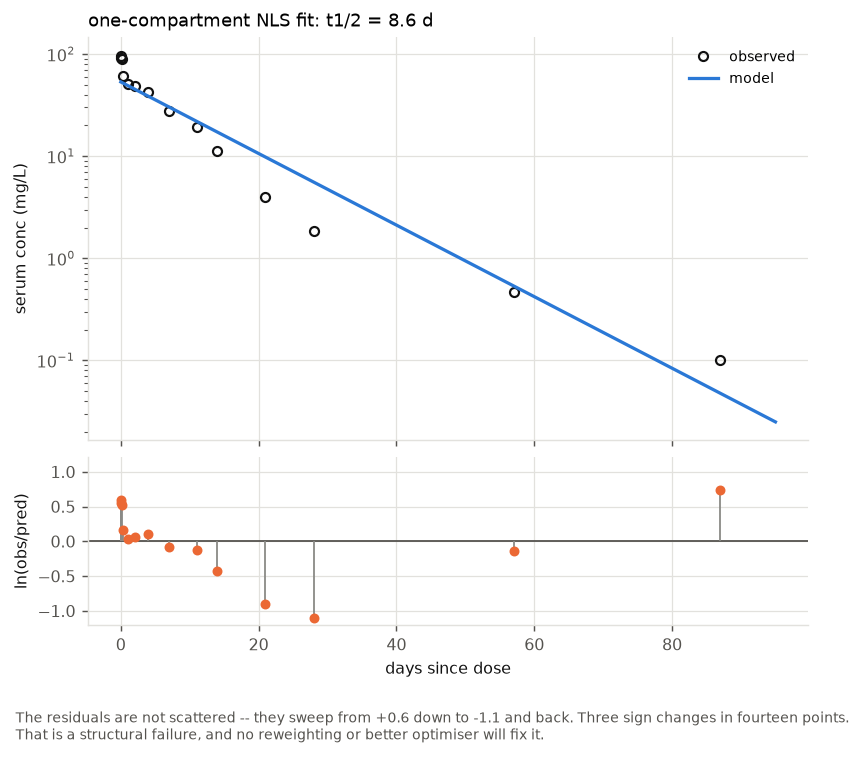

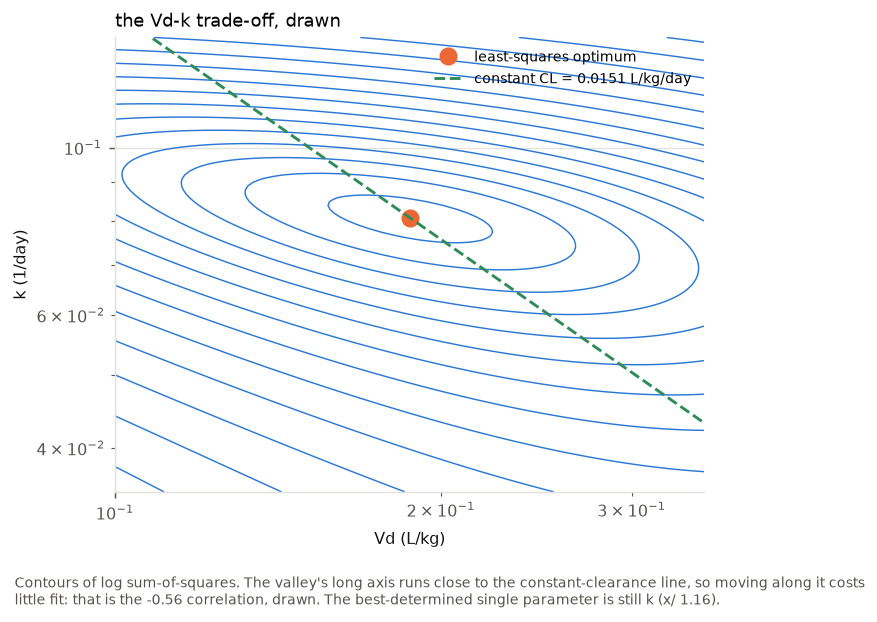

'/home/user/chiu__2022_rerun/tk_learning/figures/04_tradeoff.png'

In [7]:
# E1 -- the standard two-panel diagnostic. Look at the bottom panel first.
grid = np.linspace(0.01, 95, 400)
P.fit_and_residuals(
    t, C, grid, iv_1comp(grid, DOSE, Vd, k), iv_1comp(t, DOSE, Vd, k),
    title=f"one-compartment NLS fit: t1/2 = {half_life(k):.1f} d",
    name="04_fit_residuals.png",
    note="The residuals are not scattered -- they sweep from +0.6 down to "
         "-1.1 and back. Three sign changes in fourteen points.\n"
         "That is a structural failure, and no reweighting or better "
         "optimiser will fix it.")

# E2 -- the parameter trade-off, as the likelihood surface itself.
vv = np.linspace(np.log(0.10), np.log(0.35), 120)
kk = np.linspace(np.log(0.035), np.log(0.14), 120)
V, K = np.meshgrid(vv, kk)
SSQ = np.array([[np.sum((np.log(C) - model_log(t, v, kx)) ** 2)
                 for v in vv] for kx in kk])
fig, ax = plt.subplots(figsize=(5.4, 4.2), constrained_layout=True)
cs = ax.contour(np.exp(V), np.exp(K), np.log(SSQ), levels=14,
                colors=P.BLUE, linewidths=0.8)
ax.plot(Vd, k, "o", color=P.ORANGE, ms=9, label="least-squares optimum")
# the line of constant clearance through the optimum
vline = np.exp(vv)
ax.plot(vline, clearance(k, Vd) / vline, "--", color=P.GREEN, lw=1.6,
        label=f"constant CL = {clearance(k, Vd):.4f} L/kg/day")
ax.set(xlabel="Vd (L/kg)", ylabel="k (1/day)", xscale="log", yscale="log",
       ylim=(0.035, 0.14))
ax.set_title("the Vd-k trade-off, drawn")
ax.legend(loc="upper right")
P.save(fig, "04_tradeoff.png",
       "Contours of log sum-of-squares. The valley's long axis runs "
       "close to the constant-clearance line, so moving along it costs\n"
       "little fit: that is the -0.56 correlation, drawn. The "
       "best-determined single parameter is still k (x/ 1.16).")

### Questions

1. In section D, what fraction of the total AUC came from the extrapolated tail? Rule of thumb: above 20% and the AUC is suspect.
1. Why does CL = dose/AUC hold for a two-compartment model too? (Hint: integrate dA/dt = -CL*C over all time.)
1. Section C: CL is better determined than Vd but worse than k. Work out why from var(lnVd + lnk) = var(lnVd) + var(lnk) + 2cov -- which term has to dominate for CL to beat BOTH?
1. If you had only the first 7 days of this curve, which of Vd, k and CL would still be well estimated?

### Exercises

1. Fit the other two monkeys and compare. Do their intervals overlap?
1. Refit using only t >= 7 days. The residual pattern should improve and the half-life should lengthen. By how much? You have now rediscovered, by a different route, the terminal-phase judgement call from lesson 03.
1. Change model_log to fit on the linear scale instead (return the concentration, pass C not log C). Which points now dominate the fit, and what happens to the half-life?